# Border strips and nighttime lights

Buffer the shared border by 50 km, clip the ethnic polygons to it, then dissolve so each ethnicity-country side is one geometry. Without the dissolve, zonal_stats returns one row per polygon fragment and the panel silently doubles.

**Expected:** 12 groups keep a buffer, 31 polygons before the dissolve, 24 units after. Groups 532 and 1023 have no shared border; 134, 789 and 829 do not reach the strip.

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

import config
import buffer, ntl

import figures
figures.setup()

In [2]:
group_ids = pd.read_csv(config.WORK / 'clean_did_groups.csv')['G1ID'].tolist()
buffers, dropped = buffer.run(group_ids)

buffer CRS: ESRI:102023, width 50 km

    AO -> AO via FIPS_10: Angola
    CG -> CG via FIPS_10: Democratic Republic of the Congo
  124 Bambundu (AO/CG): ok, 2 polygons
    AO -> AO via FIPS_10: Angola
    ZA -> ZA via FIPS_10: Zambia
  134 Bankoya and Wambuela (AO/ZA): only [] reaches the strip
    ET -> ET via FIPS_10: Ethiopia
    SU -> SU via FIPS_10: Sudan
  173 Berta (ET/SU): ok, 2 polygons
    CM -> CM via FIPS_10: Cameroon
    NI -> NI via FIPS_10: Nigeria
  224 Bute (CM/NI): ok, 2 polygons
    CD -> CD via FIPS_10: Chad
    SU -> SU via FIPS_10: Sudan
  321 Dago (CD/SU): ok, 2 polygons
    CM -> CM via FIPS_10: Cameroon
    NI -> NI via FIPS_10: Nigeria
  503 Jukun and Idoma (CM/NI): ok, 5 polygons
    SU -> SU via FIPS_10: Sudan
    UG -> UG via FIPS_10: Uganda
  532 Karamojo (SU/UG): no shared border
    ET -> ET via FIPS_10: Ethiopia
    SU -> SU via FIPS_10: Sudan
  574 Koma (ET/SU): ok, 4 polygons
    CM -> CM via FIPS_10: Cameroon
    NI -> NI via FIPS_10: Nigeria
  685 

In [3]:
buffers[['G1ID', 'FIPS_CNTRY', 'area_km2']].round(0)

,G1ID,FIPS_CNTRY,area_km2
0,124,AO,5512.0
1,124,CG,2454.0
2,173,ET,9509.0
3,173,SU,5551.0
4,224,CM,1742.0
5,224,NI,323.0
6,321,CD,386.0
7,321,SU,200.0
8,503,CM,2868.0
9,503,NI,8240.0


In [4]:
lights = ntl.run(buffers)
lights.head()

rasters found: 34
  2013 (simVIIRS)
  1992 (calDMSP)
  1993 (calDMSP)
  1994 (calDMSP)
  1995 (calDMSP)
  1996 (calDMSP)
  1997 (calDMSP)
  1998 (calDMSP)
  1999 (calDMSP)
  2000 (calDMSP)
  2001 (calDMSP)
  2002 (calDMSP)
  2003 (calDMSP)
  2004 (calDMSP)
  2005 (calDMSP)
  2006 (calDMSP)
  2007 (calDMSP)
  2008 (calDMSP)
  2009 (calDMSP)
  2010 (calDMSP)
  2011 (calDMSP)
  2012 (calDMSP)
  2013 (calDMSP)
  2014 (simVIIRS)
  2015 (simVIIRS)
  2016 (simVIIRS)
  2017 (simVIIRS)
  2018 (simVIIRS)
  2019 (simVIIRS)
  2020 (simVIIRS)
  2021 (simVIIRS)
  2022 (simVIIRS)
  2023 (simVIIRS)
  2024 (simVIIRS)
missing radiance values: 0
largest pixel count variation:
          min   max  spread_pct
unit_id                        
1179_SO    79    83    5.063291
1192_ZA  4861  4944    1.707468
321_CD    478   485    1.464435
503_CM   3577  3603    0.726866
124_CG   3081  3101    0.649140


,G1ID,FIPS_CNTRY,unit_id,name,year,source,ntl_mean,ntl_count,ln_ntl
0,1095,CM,1095_CM,Tikar,1992,calDMSP,0.0,1944,-4.60517
1,1095,CM,1095_CM,Tikar,1993,calDMSP,0.0,1944,-4.60517
2,1095,CM,1095_CM,Tikar,1994,calDMSP,0.0,1944,-4.60517
3,1095,CM,1095_CM,Tikar,1995,calDMSP,0.0,1944,-4.60517
4,1095,CM,1095_CM,Tikar,1996,calDMSP,0.0,1944,-4.60517


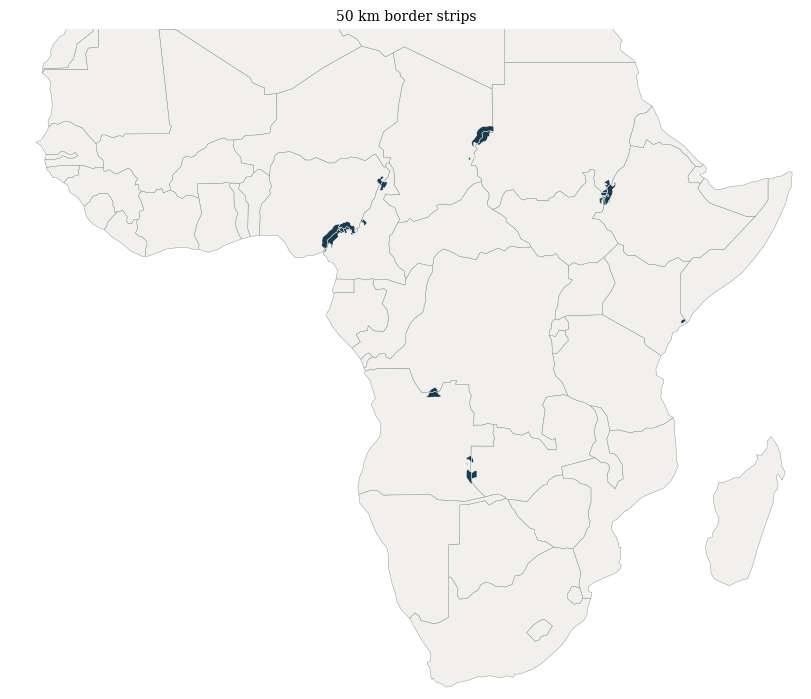

In [5]:
import geopandas as gpd

world = gpd.read_file(config.COUNTRIES_110M)
africa = world[world["CONTINENT"] == "Africa"]

ax = africa.plot(figsize=(8, 8), color="#F2F0EC", edgecolor=config.GREY, lw=0.3)
buffers.plot(ax=ax, color=config.NAVY, edgecolor="white", lw=0.3)
ax.set_xlim(-20, 52)
ax.set_ylim(-35, 25)
ax.set_axis_off()
ax.set_title("50 km border strips")
plt.show()